# 01_data_preprocessing.ipynb

# P1 – Data Preprocessing Pipeline (Mammography BI-RADS Reports)

This notebook performs the complete data preprocessing workflow for the Mammography NLP project, from the translated dataset through to the final model-ready `processed_dataset.csv` and train/validation/test splits.

## Objectives

- Load translated dataset
- Dataset audit (missing values, duplicates, class distribution, report statistics)
- Exploratory Data Analysis (EDA)
- Translation validation sampling
- Missing value & duplicate handling
- Clinical text preprocessing:
  - Unicode & whitespace normalization
  - Clinical abbreviation expansion
  - Negation preservation
  - Measurement preservation
  - Laterality preservation
  - Target leakage removal (BI-RADS mentions / explicit diagnosis terms)
- Preservation validation (did we accidentally destroy negations/measurements/laterality?)
- Post-processing quality checks
- Save `processed_dataset.csv`
- Stratified Train / Validation / Test split

> **Note:** Translation has already been completed. This notebook starts from the translated English dataset (`train_translated.xlsx`).

> **Editing note:** Every path used in this notebook is derived from the single `BASE_DIR` variable in the **Configuration** cell below. To point this notebook at a different project folder, dataset location, or output location, change `BASE_DIR` (and `RAW_DATA_PATH` if your raw file lives somewhere unusual) — nothing else needs to be touched.

In [2]:
# ==========================================
# Imports
# ==========================================

import os
import re
import json
import unicodedata
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import train_test_split

# Optional (used if installed — the notebook degrades gracefully if not)
try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except ImportError:
    HAS_WORDCLOUD = False

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## 1. Configuration

**This is the only cell you should need to edit.** `BASE_DIR` is the single common variable — every input and output path below is derived from it, so changing project location, drive folder, etc. only requires editing `BASE_DIR` (and `RAW_DATA_PATH` if your raw file isn't in the default subfolder).

In [3]:
# ============================================================
# GLOBAL CONFIGURATION — EDIT ONLY THIS CELL
# ============================================================

# --- 1) The ONE variable that controls where everything is read from / written to ---
BASE_DIR = '/content/drive/MyDrive/NLP_Research_Project'

# --- 2) Where the raw translated dataset lives (relative to BASE_DIR by default) ---
RAW_DATA_PATH = os.path.join(
    BASE_DIR,
   'data',
    'raw/translated_train.xlsx'
)

# --- 3) Column names in the raw dataset ---
TEXT_COLUMN = 'report'
LABEL_COLUMN = 'target'
ID_COLUMN = 'ID'

# ============================================================
# Everything below this line is DERIVED from BASE_DIR.
# You should not need to edit it.
# ============================================================

DIRS = {
    'figures':     os.path.join(BASE_DIR, 'results', 'figures'),
    'audit':       os.path.join(BASE_DIR, 'results', 'audit'),
    'translation': os.path.join(BASE_DIR, 'results', 'translation'),
    'quality':     os.path.join(BASE_DIR, 'results', 'quality'),
    'processed':   os.path.join(BASE_DIR, 'data', 'processed'),
    'splits':      os.path.join(BASE_DIR, 'data', 'splits'),
}

for _d in DIRS.values():
    os.makedirs(_d, exist_ok=True)

# Convenience: standard output file paths, all built from DIRS/BASE_DIR
PATHS = {
    'audit_summary':          os.path.join(DIRS['audit'], 'audit_summary.csv'),
    'leakage_report':         os.path.join(DIRS['audit'], 'leakage_report.csv'),
    'class_distribution_png': os.path.join(DIRS['figures'], 'class_distribution.png'),
    'report_length_hist_png': os.path.join(DIRS['figures'], 'report_length_histogram.png'),
    'report_length_box_png':  os.path.join(DIRS['figures'], 'report_length_boxplot.png'),
    'wordcloud_png':          os.path.join(DIRS['figures'], 'wordcloud.png'),
    'dataset_summary_csv':    os.path.join(DIRS['audit'], 'dataset_summary_table.csv'),
    'translation_sample':     os.path.join(DIRS['translation'], 'translation_validation_sample.csv'),
    'preservation_check':     os.path.join(DIRS['quality'], 'preservation_validation.csv'),
    'quality_report':         os.path.join(DIRS['quality'], 'quality_report.json'),
    'processed_dataset':      os.path.join(DIRS['processed'], 'processed_dataset.csv'),
    'train_ids':              os.path.join(DIRS['splits'], 'train_ids.csv'),
    'val_ids':                os.path.join(DIRS['splits'], 'validation_ids.csv'),
    'test_ids':                os.path.join(DIRS['splits'], 'test_ids.csv'),
    'train_full':              os.path.join(DIRS['splits'], 'train.csv'),
    'val_full':                os.path.join(DIRS['splits'], 'validation.csv'),
    'test_full':                os.path.join(DIRS['splits'], 'test.csv'),
}

print('BASE_DIR   :', BASE_DIR)
print('RAW_DATA_PATH:', RAW_DATA_PATH)
for k, v in DIRS.items():
    print(f"  [{k}] -> {v}")

BASE_DIR   : /content/drive/MyDrive/NLP_Research_Project
RAW_DATA_PATH: /content/drive/MyDrive/NLP_Research_Project/data/raw/translated_train.xlsx
  [figures] -> /content/drive/MyDrive/NLP_Research_Project/results/figures
  [audit] -> /content/drive/MyDrive/NLP_Research_Project/results/audit
  [translation] -> /content/drive/MyDrive/NLP_Research_Project/results/translation
  [quality] -> /content/drive/MyDrive/NLP_Research_Project/results/quality
  [processed] -> /content/drive/MyDrive/NLP_Research_Project/data/processed
  [splits] -> /content/drive/MyDrive/NLP_Research_Project/data/splits


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Load Dataset

In [ ]:
df = pd.read_excel(RAW_DATA_PATH)
display(df.head())
print(df.shape)
print(df.info())

,ID,target,report
0,Acc1,2,Clinical indication:\n\n tracking.\n\nFindings...
1,Acc3,2,Clinical indication:\n\n tracking.\n\nFindings...
2,Acc5,2,Clinical indication:\n\n tracking.\n\nFindings...
3,Acc6,2,Clinical indication:\n\n reassessment of chang...
4,Acc7,2,Clinical indication:\n\n reassessment of chang...


(18272, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18272 entries, 0 to 18271
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      18272 non-null  object
 1   target  18272 non-null  int64 
 2   report  18272 non-null  object
dtypes: int64(1), object(2)
memory usage: 428.4+ KB
None


## 3. Dataset Audit

Baseline audit of the *raw* translated dataset, before any cleaning.

In [ ]:
audit = {
    'rows': len(df),
    'columns': len(df.columns),
    'missing_text': int(df[TEXT_COLUMN].isnull().sum()),
    'missing_label': int(df[LABEL_COLUMN].isnull().sum()),
    'missing_total': df.isnull().sum().to_dict(),
    'duplicate_rows_full': int(df.duplicated().sum()),
    'duplicate_reports_text': int(df[TEXT_COLUMN].duplicated().sum()),
    'empty_reports': int((df[TEXT_COLUMN].fillna('').str.strip() == '').sum()),
    'n_classes': int(df[LABEL_COLUMN].nunique()),
}
pd.DataFrame([audit]).to_csv(PATHS['audit_summary'], index=False)
audit

{'rows': 18272,
 'columns': 3,
 'missing_text': 0,
 'missing_label': 0,
 'missing_total': {'ID': 0, 'target': 0, 'report': 0},
 'duplicate_rows_full': 0,
 'duplicate_reports_text': 9093,
 'empty_reports': 0,
 'n_classes': 7}

## 4. Handle Missing Values & Duplicates

Rows with a missing report or missing label cannot be used for supervised classification and are dropped. Exact duplicate reports are removed (keeping the first occurrence) so the model isn't trained/evaluated on repeated samples.

In [ ]:
n_before = len(df)

# Drop rows with missing text or missing label
df = df.dropna(subset=[TEXT_COLUMN, LABEL_COLUMN]).copy()

# Drop rows where the report is empty / whitespace-only
df = df[df[TEXT_COLUMN].astype(str).str.strip() != ''].copy()

# Drop exact duplicate reports (keep first)
n_dupes = int(df[TEXT_COLUMN].duplicated().sum())
df = df.drop_duplicates(subset=[TEXT_COLUMN], keep='first').copy()

df = df.reset_index(drop=True)
n_after = len(df)

print(f"Rows before cleaning : {n_before}")
print(f"Duplicate reports removed : {n_dupes}")
print(f"Rows after cleaning  : {n_after}")
print(f"Total rows dropped   : {n_before - n_after}")

Rows before cleaning : 18272
Duplicate reports removed : 9093
Rows after cleaning  : 9179
Total rows dropped   : 9093


## 5. Exploratory Data Analysis (EDA)

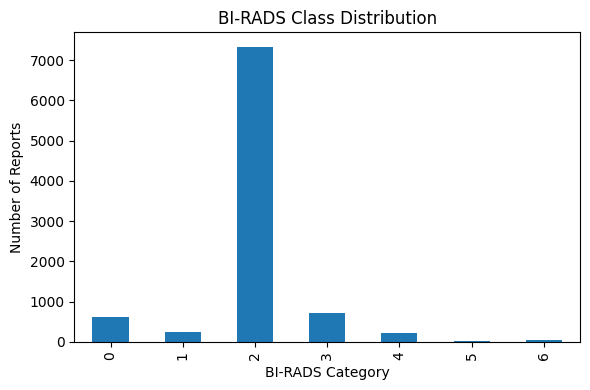

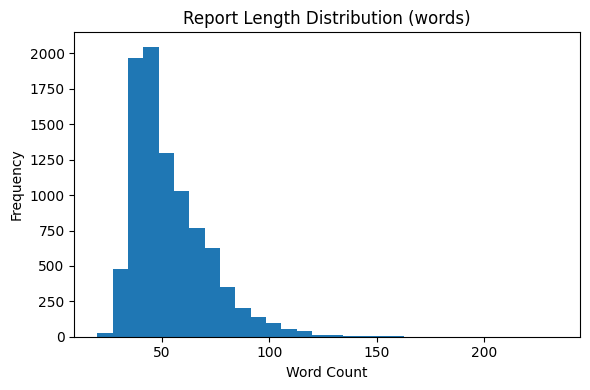

<Figure size 800x400 with 0 Axes>

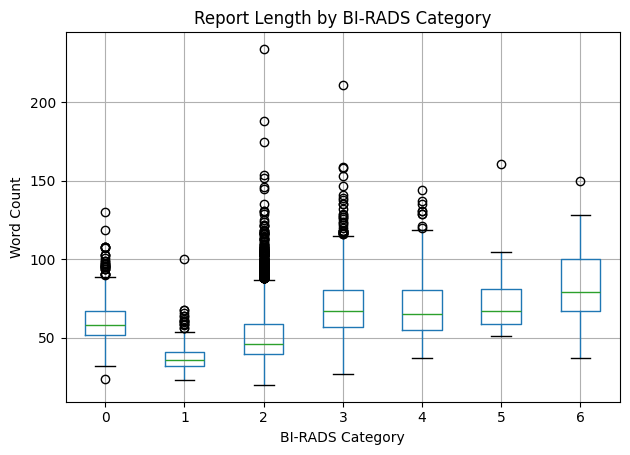

In [ ]:
df['word_count'] = df[TEXT_COLUMN].fillna('').str.split().apply(len)
df['char_count'] = df[TEXT_COLUMN].fillna('').str.len()

# --- Class distribution ---
plt.figure(figsize=(6, 4))
df[LABEL_COLUMN].value_counts().sort_index().plot(kind='bar')
plt.title('BI-RADS Class Distribution')
plt.xlabel('BI-RADS Category')
plt.ylabel('Number of Reports')
plt.tight_layout()
plt.savefig(PATHS['class_distribution_png'])
plt.show()

# --- Report length histogram ---
plt.figure(figsize=(6, 4))
plt.hist(df['word_count'], bins=30)
plt.title('Report Length Distribution (words)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(PATHS['report_length_hist_png'])
plt.show()

# --- Report length boxplot (by class, to catch length-based leakage / imbalance) ---
plt.figure(figsize=(8, 4))
df.boxplot(column='word_count', by=LABEL_COLUMN)
plt.title('Report Length by BI-RADS Category')
plt.suptitle('')
plt.xlabel('BI-RADS Category')
plt.ylabel('Word Count')
plt.tight_layout()
plt.savefig(PATHS['report_length_box_png'])
plt.show()

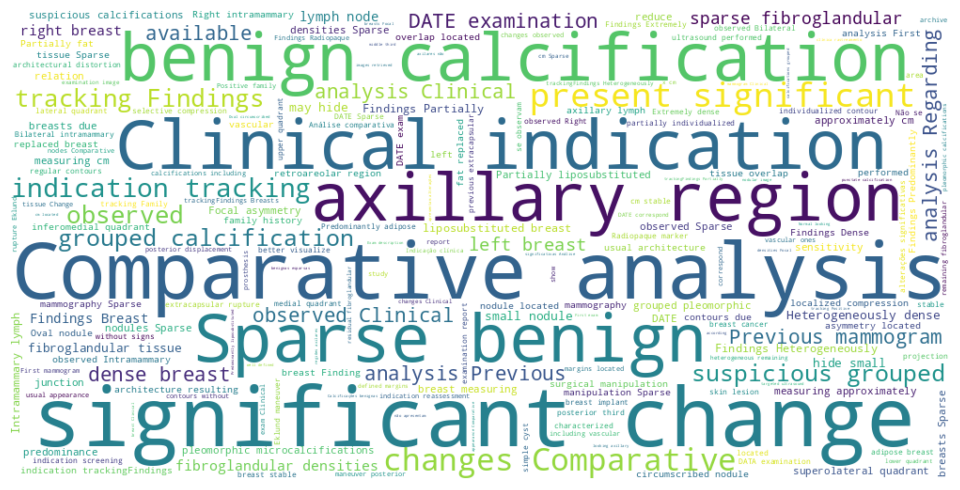

In [ ]:
# --- Word cloud (optional; skipped gracefully if wordcloud isn't installed) ---
if HAS_WORDCLOUD:
    text_blob = ' '.join(df[TEXT_COLUMN].astype(str).tolist())
    wc = WordCloud(width=1000, height=500, background_color='white').generate(text_blob)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(PATHS['wordcloud_png'])
    plt.show()
else:
    print("wordcloud not installed — skipping word cloud. Run `pip install wordcloud` to enable it.")

In [ ]:
# --- Dataset summary table ---
summary_table = pd.DataFrame({
    'metric': [
        'n_reports', 'n_classes', 'avg_word_count', 'median_word_count',
        'min_word_count', 'max_word_count', 'avg_char_count',
    ],
    'value': [
        len(df), df[LABEL_COLUMN].nunique(),
        df['word_count'].mean(), df['word_count'].median(),
        df['word_count'].min(), df['word_count'].max(),
        df['char_count'].mean(),
    ]
})
summary_table.to_csv(PATHS['dataset_summary_csv'], index=False)
summary_table

,metric,value
0,n_reports,9179.000000
1,n_classes,7.000000
2,avg_word_count,53.910339
3,median_word_count,49.000000
4,min_word_count,20.000000
5,max_word_count,234.000000
6,avg_char_count,444.885935


## 6. Translation Validation Sample

A random sample is exported for manual review, checking that clinical terminology, negation, measurements, and laterality survived translation.

In [ ]:
sample = df.sample(min(50, len(df)), random_state=RANDOM_STATE)
sample.to_csv(PATHS['translation_sample'], index=False)
sample.head()

,ID,target,report,word_count,char_count
624,Acc1202,2,Clinical indication:\n\n tracking.\n\nFindings...,44,364
8171,Acc19673,3,Clinical indication:\n\nTracking.\n\n Reductio...,90,677
9168,Acc22738,2,Clinical indication:\n\ntracking.\n\nFindings:...,43,362
7143,Acc16683,2,Clinical indication:\n\ntracking.\n\nFindings:...,37,325
1817,Acc3897,2,Clinical indication:\n\n tracking.\n\nFindings...,42,380


## 7. Clinical Text Preprocessing

This is the core of Phase 2. Mammography reports need domain-aware preprocessing — generic NLP cleaning (aggressive lowercasing, punctuation stripping, stopword removal) can silently destroy clinically meaningful information:

- **Negation** ("no evidence of malignancy" vs "evidence of malignancy") completely flips clinical meaning.
- **Measurements** ("2.5 cm", "3x2x1.5 cm") must keep their decimals/numbers intact.
- **Laterality** ("left", "right", "bilateral") is often clinically critical and commonly abbreviated (`rt`, `lt`, `b/l`).
- **BI-RADS category mentions** in the report text are **target leakage** — since BI-RADS category is exactly what we're predicting, any explicit mention of it in the input text must be removed.

The pipeline below runs these steps **in a fixed order** so each step operates on a well-defined input:

1. Unicode normalization (NFKC)
2. Lowercasing
3. Remove URLs / HTML artifacts
4. Whitespace normalization
5. Clinical abbreviation expansion (so downstream steps see full words, e.g. `rt` → `right`)
6. Negation normalization (standardize negation cues, e.g. `w/o` → `without`, `r/o` → `rule out`)
7. Punctuation cleanup that **preserves** decimal points in measurements and clinically relevant punctuation
8. Target leakage removal (BI-RADS category mentions + explicit diagnosis terms)


In [ ]:
# --- Clinical abbreviation dictionary ---
# Extend this dictionary as you find more abbreviations in your reports.
# Applied as whole-word, case-insensitive replacements.
CLINICAL_ABBREVIATIONS = {
    'yo': 'year old',
    'y/o': 'year old',
    'hx': 'history',
    'fh': 'family history',
    'f/u': 'follow up',
    'r/o': 'rule out',
    'w/o': 'without',
    'w/': 'with',
    'b/l': 'bilateral',
    'bilat': 'bilateral',
    'rt': 'right',
    'lt': 'left',
    'usg': 'ultrasound',
    'us': 'ultrasound',
    'mmg': 'mammogram',
    'mri': 'mri',
    'dx': 'diagnosis',
    'hp': 'histopathology',
    'wnl': 'within normal limits',
    'lat': 'laterality',
    'assess': 'assessment',
    'recc': 'recommendation',
    'yrs': 'years',
}

def expand_abbreviations(text, abbrev_dict=CLINICAL_ABBREVIATIONS):
    for abbr, full in abbrev_dict.items():
        pattern = r'(?<![\w/]){}(?![\w/])'.format(re.escape(abbr))
        text = re.sub(pattern, full, text, flags=re.IGNORECASE)
    return text

In [ ]:
# --- Negation handling ---
# We do NOT remove stopwords in this pipeline, which is deliberate: negation words
# (no, not, without, denies, negative, ...) are stopwords in generic NLP but are
# clinically essential here. This function only standardizes informal negation
# shorthand into full words so downstream models/tokenizers see consistent tokens.
NEGATION_TERMS = [
    'no', 'not', 'without', 'denies', 'denied', 'negative', 'absence of',
    'absent', 'ruled out', 'rule out', 'unremarkable', "n't",
]

NEGATION_NORMALIZATION = {
    r'\bw/o\b': 'without',
    r'\br/o\b': 'rule out',
    r'\bneg\b': 'negative',
    r'\bnon-?': 'non ',
}

def normalize_negations(text):
    for pattern, repl in NEGATION_NORMALIZATION.items():
        text = re.sub(pattern, repl, text, flags=re.IGNORECASE)
    return text

def count_negations(text):
    text = str(text).lower()
    return sum(len(re.findall(r'\b' + re.escape(term) + r'\b', text)) for term in NEGATION_TERMS)

In [ ]:
# --- Measurement handling ---
# Matches patterns like "2.5 cm", "3 x 2 x 1.5 cm", "12mm"
MEASUREMENT_PATTERN = re.compile(
    r'\b\d+(\.\d+)?\s*(x|X)?\s*(\d+(\.\d+)?\s*(x|X)?\s*)*(cm|mm|centimeters?|millimeters?)\b'
)

def count_measurements(text):
    return len(MEASUREMENT_PATTERN.findall(str(text)))

def preserve_measurements(text):
    """Protects measurement spans from later punctuation stripping by
    temporarily replacing internal spaces with a placeholder, then restoring
    them after cleanup. Returns the text unchanged in content, just guarded."""
    def _guard(m):
        return m.group(0).replace(' ', '§')
    return MEASUREMENT_PATTERN.sub(_guard, text)

def restore_measurements(text):
    return text.replace('§', ' ')

In [ ]:
# --- Laterality handling ---
# Laterality abbreviations are expanded in expand_abbreviations() (rt/lt/b/l ->
# right/left/bilateral). This function just measures how many laterality
# mentions are present, so we can confirm none were lost during processing.
LATERALITY_TERMS = ['left', 'right', 'bilateral', 'unilateral']

def count_laterality(text):
    text = str(text).lower()
    return sum(len(re.findall(r'\b' + term + r'\b', text)) for term in LATERALITY_TERMS)

In [ ]:
# --- Target leakage removal ---
# BI-RADS category mentions in the report text ARE the label — they must be
# removed so the model can't trivially "cheat". We also strip a small set of
# explicit final-diagnosis terms that effectively restate the outcome.
LEAKAGE_PATTERNS = [
    r"\bbi[\-\s]?rads?\b\s*[:\-]?\s*(category)?\s*[0-6][a-c]?\b",
    r"\bcategory\s*[0-6][a-c]?\b",
]

LEAKAGE_TERMS = [
    'malignant', 'malignancy', 'benign', 'carcinoma',
    'histopathology confirmed', 'biopsy-proven', 'biopsy proven',
]

def remove_leakage(text):
    for pattern in LEAKAGE_PATTERNS:
        text = re.sub(pattern, ' ', text, flags=re.IGNORECASE)
    for term in LEAKAGE_TERMS:
        text = re.sub(r"\b" + re.escape(term) + r"\b", ' ', text, flags=re.IGNORECASE)
    return text

def detect_leakage(text):
    text = str(text).lower()
    hits = []
    for pattern in LEAKAGE_PATTERNS:
        hits += re.findall(pattern, text)
    hits += [t for t in LEAKAGE_TERMS if t in text]
    return hits

# Log which raw reports contained leakage terms, before we remove them
df['leakage_terms_found'] = df[TEXT_COLUMN].apply(detect_leakage)
df[[ID_COLUMN, 'leakage_terms_found']].to_csv(PATHS['leakage_report'], index=False)
print(f"Reports containing leakage terms: {(df['leakage_terms_found'].str.len() > 0).sum()} / {len(df)}")

Reports containing leakage terms: 8624 / 9179


In [ ]:
def clean_punctuation(text):
    """Removes stray/junk characters (bullets, special symbols) while keeping
    punctuation that matters clinically: decimal points, hyphens, slashes,
    parentheses, percent signs, commas."""
    text = re.sub(r'[^a-z0-9\.\,\-\/\%\(\)\s§]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def preprocess_report(text):
    """Full clinical preprocessing pipeline, run in a fixed order.
    Returns the cleaned, leakage-free, model-ready text."""
    text = str(text)

    # 1) Unicode normalization
    text = unicodedata.normalize('NFKC', text)

    # 2) Lowercase
    text = text.lower()

    # 3) Remove URLs / HTML artifacts
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)

    # 4) Whitespace normalization
    text = re.sub(r'\s+', ' ', text).strip()

    # 5) Clinical abbreviation expansion (before punctuation cleanup, since
    #    abbreviations like "f/u" and "w/o" rely on the slash still being there)
    text = expand_abbreviations(text)

    # 6) Negation normalization
    text = normalize_negations(text)

    # 7) Guard measurements, then strip stray punctuation, then unguard
    text = preserve_measurements(text)
    text = clean_punctuation(text)
    text = restore_measurements(text)

    # 8) Target leakage removal (last, so it also catches any leakage terms
    #    that abbreviation expansion may have spelled out in full)
    text = remove_leakage(text)

    # Final tidy-up: collapse repeated/orphaned punctuation left behind by
    # leakage removal (e.g. "category ." -> "category.") and whitespace
    text = re.sub(r'\s+([\.,])', r'\1', text)
    text = re.sub(r'[\.,]{2,}', '.', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.strip(' .,-')

    return text


df['processed_text'] = df[TEXT_COLUMN].apply(preprocess_report)
df[[TEXT_COLUMN, 'processed_text']].head()

,report,processed_text
0,Clinical indication:\n\n tracking.\n\nFindings...,clinical indication tracking. findings partial...
1,Clinical indication:\n\n tracking.\n\nFindings...,clinical indication tracking. findings partial...
2,Clinical indication:\n\n tracking.\n\nFindings...,clinical indication tracking. findings partial...
3,Clinical indication:\n\n reassessment of chang...,clinical indication reassessment of changes ob...
4,Clinical indication:\n\n reassessment of chang...,clinical indication reassessment of changes ob...


## 8. Preservation Validation

A sanity check that the pipeline preserved what it was supposed to preserve: negation cues, measurements, and laterality mentions should be roughly stable before → after (leakage terms should have dropped to ~0).

In [ ]:
preservation = pd.DataFrame({
    'negation_before': df[TEXT_COLUMN].apply(count_negations),
    'negation_after': df['processed_text'].apply(count_negations),
    'measurements_before': df[TEXT_COLUMN].apply(count_measurements),
    'measurements_after': df['processed_text'].apply(count_measurements),
    'laterality_before': df[TEXT_COLUMN].apply(count_laterality),
    'laterality_after': df['processed_text'].apply(count_laterality),
    'leakage_terms_after': df['processed_text'].apply(lambda t: len(detect_leakage(t))),
})

preservation_summary = preservation.sum().to_frame('total').reset_index().rename(columns={'index': 'metric'})
preservation_summary.to_csv(PATHS['preservation_check'], index=False)
preservation_summary

,metric,total
0,negation_before,25401
1,negation_after,25401
2,measurements_before,2601
3,measurements_after,2601
4,laterality_before,8494
5,laterality_after,8499
6,leakage_terms_after,181


## 9. Post-Processing Quality Checks

In [ ]:
df['processed_word_count'] = df['processed_text'].str.split().apply(len)

quality = {
    'empty_processed_reports': int((df['processed_text'].str.len() == 0).sum()),
    'duplicate_processed_reports': int(df['processed_text'].duplicated().sum()),
    'unique_labels': int(df[LABEL_COLUMN].nunique()),
    'avg_word_count_raw': float(df['word_count'].mean()),
    'avg_word_count_processed': float(df['processed_word_count'].mean()),
    'remaining_leakage_reports': int((df['processed_text'].apply(lambda t: len(detect_leakage(t))) > 0).sum()),
}

with open(PATHS['quality_report'], 'w') as f:
    json.dump(quality, f, indent=2)

quality

{'empty_processed_reports': 0,
 'duplicate_processed_reports': 614,
 'unique_labels': 7,
 'avg_word_count_raw': 53.91033881686458,
 'avg_word_count_processed': 52.54602897919163,
 'remaining_leakage_reports': 181}

## 10. Save Final Processed Dataset

We keep both the raw (translated) text and the processed text in the saved file — the raw text is useful for error analysis / SHAP-LIME later, while `text` (processed) is what feeds every downstream model pipeline (N-gram, classical ML, deep learning).

In [ ]:
processed = df[[ID_COLUMN, TEXT_COLUMN, 'processed_text', LABEL_COLUMN]].copy()
processed.columns = ['id', 'raw_text', 'text', 'label']

processed.to_csv(PATHS['processed_dataset'], index=False)
print(f"Saved processed dataset -> {PATHS['processed_dataset']}")
processed.head()

Saved processed dataset -> /content/drive/MyDrive/NLP_Research_Project/data/processed/processed_dataset.csv


,id,raw_text,text,label
0,Acc1,Clinical indication:\n\n tracking.\n\nFindings...,clinical indication tracking. findings partial...,2
1,Acc3,Clinical indication:\n\n tracking.\n\nFindings...,clinical indication tracking. findings partial...,2
2,Acc5,Clinical indication:\n\n tracking.\n\nFindings...,clinical indication tracking. findings partial...,2
3,Acc6,Clinical indication:\n\n reassessment of chang...,clinical indication reassessment of changes ob...,2
4,Acc7,Clinical indication:\n\n reassessment of chang...,clinical indication reassessment of changes ob...,2


## 11. Train / Validation / Test Split

Stratified 70/15/15 split on the processed dataset, so class balance is preserved across splits.

In [ ]:
train, temp = train_test_split(
    processed,
    test_size=0.30,
    stratify=processed['label'],
    random_state=RANDOM_STATE,
)

val, test = train_test_split(
    temp,
    test_size=0.50,
    stratify=temp['label'],
    random_state=RANDOM_STATE,
)

# ID-only files (for reproducibility / cross-pipeline alignment)
train[['id']].to_csv(PATHS['train_ids'], index=False)
val[['id']].to_csv(PATHS['val_ids'], index=False)
test[['id']].to_csv(PATHS['test_ids'], index=False)

# Full split files (id, raw_text, text, label) — convenient for model notebooks
train.to_csv(PATHS['train_full'], index=False)
val.to_csv(PATHS['val_full'], index=False)
test.to_csv(PATHS['test_full'], index=False)

print('Train:', train.shape, ' Validation:', val.shape, ' Test:', test.shape)
print('Train class balance:')
print(train['label'].value_counts(normalize=True).sort_index())

Train: (6425, 4)  Validation: (1377, 4)  Test: (1377, 4)
Train class balance:
label
0    0.065837
1    0.027393
2    0.797821
3    0.077510
4    0.023346
5    0.003113
6    0.004981
Name: proportion, dtype: float64


## 12. Final Checklist

In [ ]:
print('Audit Complete')
print('Missing Values & Duplicates Handled')
print('EDA Complete (class distribution, histogram, boxplot, word cloud, summary table)')
print('Translation Validation Sample Exported')
print('Clinical Abbreviations Expanded')
print('Negation Normalized & Preservation Validated')
print('Measurements Preserved & Preservation Validated')
print('Laterality Preserved & Preservation Validated')
print('Target Leakage (BI-RADS mentions) Removed & Validated')
print('Post-Processing Quality Checks Complete')
print('Processed Dataset Saved:', PATHS['processed_dataset'])
print('Train/Validation/Test Splits Saved:', DIRS['splits'])

Audit Complete
Missing Values & Duplicates Handled
EDA Complete (class distribution, histogram, boxplot, word cloud, summary table)
Translation Validation Sample Exported
Clinical Abbreviations Expanded
Negation Normalized & Preservation Validated
Measurements Preserved & Preservation Validated
Laterality Preserved & Preservation Validated
Target Leakage (BI-RADS mentions) Removed & Validated
Post-Processing Quality Checks Complete
Processed Dataset Saved: /content/drive/MyDrive/NLP_Research_Project/data/processed/processed_dataset.csv
Train/Validation/Test Splits Saved: /content/drive/MyDrive/NLP_Research_Project/data/splits
